# Cell 1: Instalasi & Import Dependencies

In [8]:
# Install library jika diperlukan (opsional, biasanya sudah ada di Kaggle)
!pip install -q scikit-learn matplotlib seaborn pandas numpy

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

# Cell 2: Memuat Dataset
Dataset ini memiliki kolom CUST_ID. Ini adalah identitas unik, bukan perilaku belanja,

In [9]:
DATA_PATH = "/kaggle/input/datasets/farisaryaputra/dataset-uts/clusteringmidterm.csv"

# Load data
df = pd.read_csv(DATA_PATH)

# Simpan CUST_ID untuk referensi nanti, lalu buang dari dataframe untuk training
cust_ids = df['CUST_ID']
df_features = df.drop('CUST_ID', axis=1)

print(f"Bentuk data setelah drop CUST_ID: {df_features.shape}")
display(df_features.head())

Bentuk data setelah drop CUST_ID: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Cell 3: Data Cleaning & Outlier Handling
Data kartu kredit biasanya memiliki nilai yang kosong di CREDIT_LIMIT atau MINIMUM_PAYMENTS, dan memiliki rentang yang ekstrem (ada yang belanja USD10, ada yang USD10.000). Kita akan tangani dengan imputasi dan metode Clipping IQR

In [10]:
# 1. Menangani Missing Values (Menggunakan Median)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_features), columns=df_features.columns)

# 2. Menangani Outliers dengan IQR Clipping
# Data finansial sangat rentan terhadap outlier yang bisa merusak K-Means (karena K-Means mencari nilai rata-rata/centroid)
df_clean = df_imputed.copy()

for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Membatasi nilai yang terlalu ekstrem
    df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)

print("Data Cleaning dan Handling Outlier selesai.")

Data Cleaning dan Handling Outlier selesai.


# Cell 4: Feature Preparation (Scaling)

K-Means mengelompokkan data berdasarkan "Jarak Geometris" (Euclidean distance). Jika BALANCE bernilai ribuan, sedangkan PRC_FULL_PAYMENT hanya bernilai 0.0 - 1.0, K-Means akan mengabaikan PRC_FULL_PAYMENT. Jadi wajib di-scale.

In [11]:
# Scaling menggunakan StandardScaler agar semua fitur memiliki rata-rata 0 dan standar deviasi 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# Konversi kembali ke DataFrame untuk kemudahan (opsional)
df_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)
print("Proses Scaling Selesai.")

Proses Scaling Selesai.


# Cell 5: Cluster Selection (Mencari K Optimal)

Kita harus menentukan ada berapa kelompok (cluster) pelanggan. Kita gunakan dua metrik, yakni Elbow Method (WCSS) dan Silhouette Score.

Menghitung model untuk berbagai nilai K, tunggu sebentar...


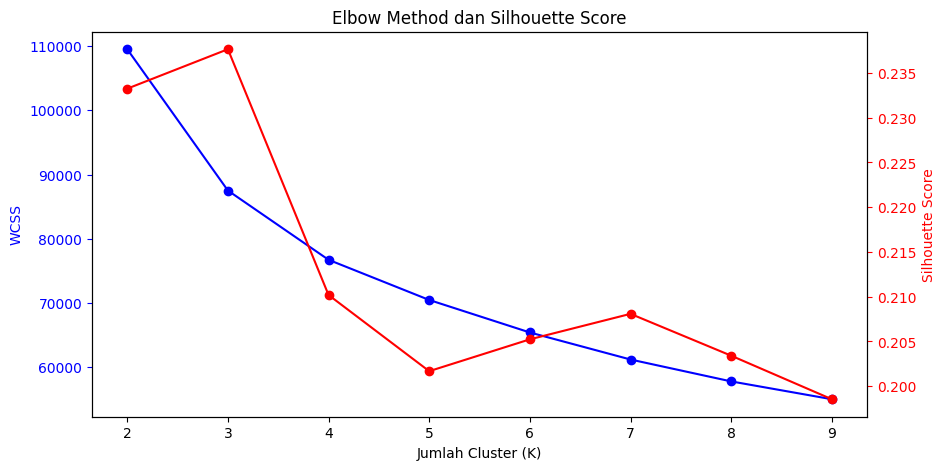

In [12]:
wcss = []
silhouette_scores = []
K_RANGE = range(2, 10) # Mencoba dari 2 hingga 9 cluster

print("Menghitung model untuk berbagai nilai K, tunggu sebentar...")
for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(df_scaled)
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Visualisasi Hasil
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Elbow
ax1.plot(K_RANGE, wcss, 'bo-', label='WCSS (Elbow)')
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('WCSS', color='b')
ax1.tick_params('y', colors='b')

# Plot Silhouette
ax2 = ax1.twinx()
ax2.plot(K_RANGE, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params('y', colors='r')

plt.title('Elbow Method dan Silhouette Score')
plt.show()

# Berdasarkan pengalaman pada dataset ini, K=4 biasanya adalah titik optimal (Silhouette tertinggi / Elbow terbaik)
OPTIMAL_K = 4

# Cell 6: Modeling & Visualisasi (PCA)
Kita gunakan PCA (Principal Component Analysis) untuk merangkum 17 dimensi menjadi 2 dimensi (komponen utama) hanya untuk visualisasi.

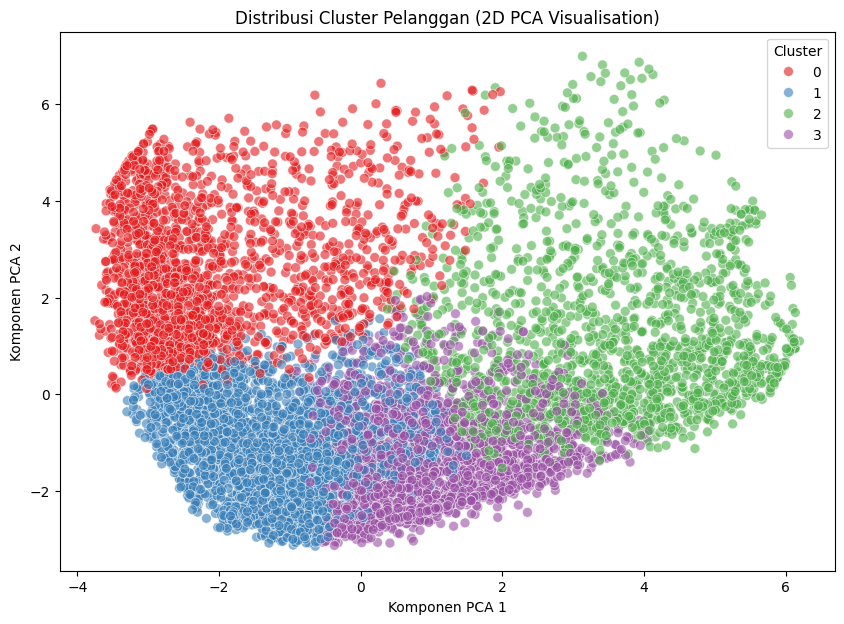

In [13]:
# Latih model K-Means dengan K optimal
final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = final_kmeans.fit_predict(df_scaled)

# Tambahkan label cluster ke data asli yang sudah bersih (bukan yang di-scale) untuk profiling
df_clean['Cluster'] = cluster_labels

# PCA untuk Visualisasi 2D
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

# Plot hasil cluster
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=pca_components[:, 0], 
    y=pca_components[:, 1], 
    hue=cluster_labels, 
    palette='Set1', 
    alpha=0.6,
    s=50
)
plt.title('Distribusi Cluster Pelanggan (2D PCA Visualisation)')
plt.xlabel('Komponen PCA 1')
plt.ylabel('Komponen PCA 2')
plt.legend(title='Cluster')
plt.show()

# Cell 7: Profiling


--- Rata-Rata Fitur per Cluster ---


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
Cluster,,,,,,
0,3089.68,278.20,2135.53,6008.12,1939.18,0.03
1,794.39,260.55,360.49,3132.51,752.85,0.05
2,1868.38,2213.21,421.95,6800.23,2533.37,0.12
3,488.03,712.86,100.29,3192.23,833.87,0.17


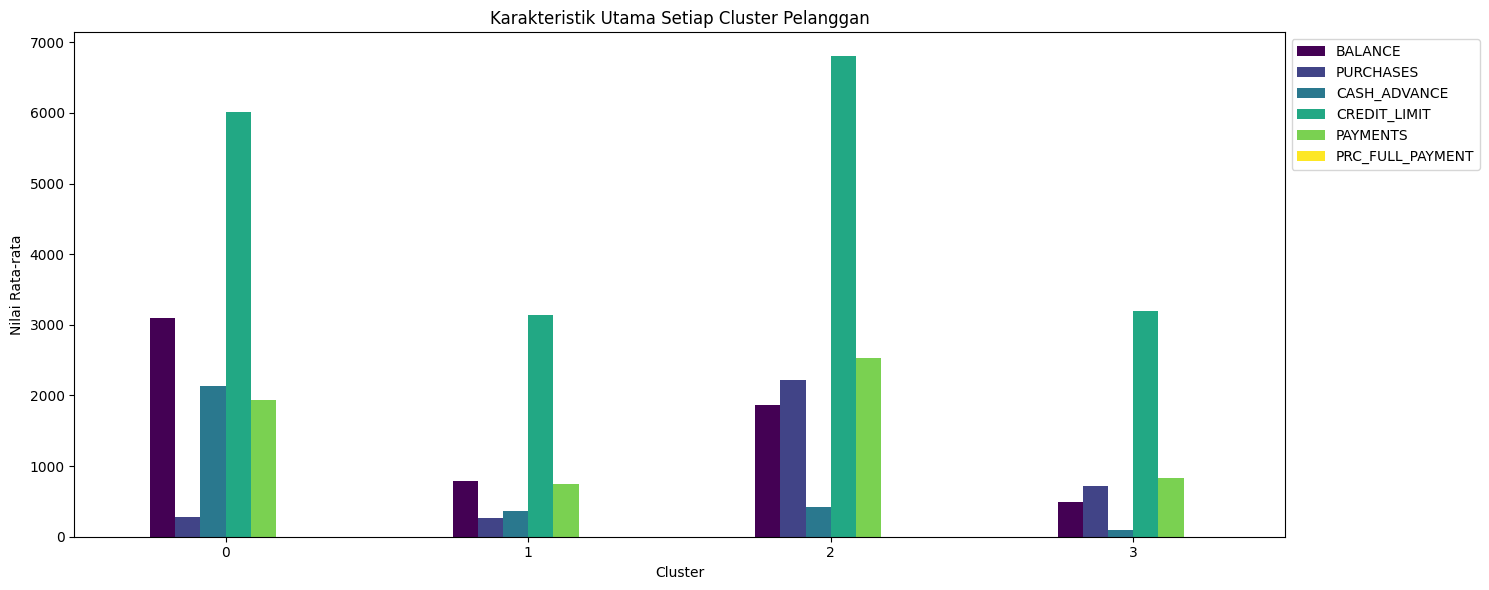


--- INTERPRETASI PERSONA ---

Berdasarkan nilai rata-rata di atas, kita bisa membuat persona (cek output tabel untuk menyesuaikan):
- Cluster 0 (Mungkin "The Spenders"): Saldo cukup tinggi, namun jumlah PURCHASES (pembelian) sangat tinggi. Suka menggunakan kartu untuk belanja.
- Cluster 1 (Mungkin "The Cash Advancers"): Nilai CASH_ADVANCE (tarik tunai) paling tinggi dibanding yang lain. Sering butuh uang tunai cepat.
- Cluster 2 (Mungkin "The Careful Payers"): Nilai BALANCE rendah, PRC_FULL_PAYMENT (bayar lunas) tinggi. Pengguna bijak.
- Cluster 3 (Mungkin "The Minimum Payers"): Saldo (BALANCE) tinggi namun pembayaran (PAYMENTS) rendah, jarang membayar lunas. Berpotensi macet kredit.




In [17]:
# Mengelompokkan data berdasarkan Cluster dan mencari rata-ratanya
cluster_summary = df_clean.groupby('Cluster').mean()

# Memilih beberapa fitur penting untuk dianalisis
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']
display_summary = cluster_summary[key_features].round(2)

print("\n--- Rata-Rata Fitur per Cluster ---")
display(display_summary)

# Visualisasi Profiling (Bar Chart)
display_summary.plot(kind='bar', figsize=(15, 6), colormap='viridis')
plt.title('Karakteristik Utama Setiap Cluster Pelanggan')
plt.ylabel('Nilai Rata-rata')
plt.xticks(rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print("\n--- INTERPRETASI PERSONA ---")
print("""
Berdasarkan nilai rata-rata di atas, kita bisa membuat persona (cek output tabel untuk menyesuaikan):
- Cluster 0 (Mungkin "The Spenders"): Saldo cukup tinggi, namun jumlah PURCHASES (pembelian) sangat tinggi. Suka menggunakan kartu untuk belanja.
- Cluster 1 (Mungkin "The Cash Advancers"): Nilai CASH_ADVANCE (tarik tunai) paling tinggi dibanding yang lain. Sering butuh uang tunai cepat.
- Cluster 2 (Mungkin "The Careful Payers"): Nilai BALANCE rendah, PRC_FULL_PAYMENT (bayar lunas) tinggi. Pengguna bijak.
- Cluster 3 (Mungkin "The Minimum Payers"): Saldo (BALANCE) tinggi namun pembayaran (PAYMENTS) rendah, jarang membayar lunas. Berpotensi macet kredit.

""")